In [ ]:
# [2] IMPLÉMENTATION COMPLÈTE DU TOKENIZER BAMBARA BPE
import re
from collections import defaultdict, Counter
from typing import List, Dict, Tuple
import sentencepiece as spm
import os


In [ ]:
class BambaraBPETokenizer:
    def __init__(self):
        self.vocab = {}
        self.merges = {}
        self.inverse_merges = {}

    def preprocess_text(self, text: str) -> str:
        """Nettoie et normalise le texte Bambara"""
        # Normaliser les apostrophes et caractères spéciaux
        text = text.replace("'", "ʼ")  # apostrophe courbe
        text = text.replace("`", "ʼ")
        text = text.replace("’", "ʼ")

        # Séparer la ponctuation
        text = re.sub(r'([!?.,:;])', r' \1 ', text)

        # Normaliser les espaces
        text = re.sub(r'\s+', ' ', text)

        return text.strip().lower()

    def get_stats(self, vocab: Dict[Tuple[str, str], int]) -> Dict[Tuple[str, str], int]:
        """Calcule les fréquences des paires de tokens"""
        pairs = defaultdict(int)
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i + 1])] += freq
        return pairs

    def merge_vocab(self, pair: Tuple[str, str], vocab: Dict[str, int]) -> Dict[str, int]:
        """Fusionne une paire dans le vocabulaire"""
        new_vocab = {}
        bigram = re.escape(' '.join(pair))
        pattern = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')

        for word, freq in vocab.items():
            new_word = pattern.sub(''.join(pair), word)
            new_vocab[new_word] = freq

        return new_vocab

    def learn_bpe(self, corpus: List[str], num_merges: int = 100):
        """Apprend les merges BPE à partir du corpus"""
        print("📚 Apprentissage BPE en cours...")

        # Prétraiter le corpus
        processed_corpus = [self.preprocess_text(text) for text in corpus]

        # Initialiser le vocabulaire avec les mots séparés par caractères
        vocab = Counter()
        for text in processed_corpus:
            words = text.split()
            for word in words:
                # Séparer en caractères avec espace, sauf pour les tokens spéciaux
                if word in ['!', '?', '.', ',', ':', ';']:
                    vocab[' ' + word + ' '] += 1
                else:
                    vocab[' '.join(list(word)) + ' '] += 1

        # Apprentissage BPE
        self.merges = {}

        for i in range(num_merges):
            pairs = self.get_stats(vocab)
            if not pairs:
                break

            best_pair = max(pairs, key=pairs.get)
            best_freq = pairs[best_pair]

            if best_freq < 2:
                break

            # Enregistrer le merge
            self.merges[best_pair] = i
            self.inverse_merges[i] = best_pair

            # Fusionner le vocabulaire
            vocab = self.merge_vocab(best_pair, vocab)

            if (i + 1) % 20 == 0:
                print(f"  ✅ Merge {i + 1}/{num_merges} complété")

        # Construire le vocabulaire final
        self.vocab = {}
        vocab_index = 0
        # Ajouter les tokens de base (caractères)
        all_chars = set()
        for word in vocab.keys():
            for char in word.replace(' ', ''):
                all_chars.add(char)

        for char in sorted(all_chars):
            self.vocab[char] = vocab_index
            vocab_index += 1
        # Ajouter les tokens fusionnés
        for merge_id in self.inverse_merges:
            token = ''.join(self.inverse_merges[merge_id])
            self.vocab[token] = vocab_index
            vocab_index += 1

        print(f"✅ BPE appris avec {len(self.merges)} merges")
        print(f"📊 Taille du vocabulaire: {len(self.vocab)} tokens")

    def encode(self, text: str) -> List[str]:
        """Encode le texte en tokens BPE"""
        text = self.preprocess_text(text)
        words = text.split()
        tokens = []

        for word in words:
            if word in ['!', '?', '.', ',', ':', ';']:
                tokens.append(word)
                continue
            # Commencer avec les caractères individuels
            current_tokens = list(word)

            # Appliquer les merges
            changed = True
            while changed and len(current_tokens) > 1:
                changed = False
                for i in range(len(current_tokens) - 1):
                    pair = (current_tokens[i], current_tokens[i + 1])
                    if pair in self.merges:
                        # Fusionner la paire
                        merged = ''.join(pair)
                        current_tokens = current_tokens[:i] + [merged] + current_tokens[i + 2:]
                        changed = True
                        break

            tokens.extend(current_tokens)

        return tokens

    def decode(self, tokens: List[str]) -> str:
        """Décode les tokens en texte"""
        return ' '.join(tokens).replace(' ', '')

    def save_model(self, filename: str):
        """Sauvegarde le modèle"""
        import json
        model_data = {
            'vocab': self.vocab,
            'merges': {f"{k[0]}|{k[1]}": v for k, v in self.merges.items()},
            'inverse_merges': self.inverse_merges
        }
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(model_data, f, ensure_ascii=False, indent=2)

    def load_model(self, filename: str):
        """Charge le modèle"""
        import json
        with open(filename, 'r', encoding='utf-8') as f:
            model_data = json.load(f)

        self.vocab = model_data['vocab']
        self.merges = {}
        for k, v in model_data['merges'].items():
            parts = k.split('|')
            self.merges[(parts[0], parts[1])] = v
        self.inverse_merges = model_data['inverse_merges']

print("✅ Tokenizer Bambara BPE implémenté!")

✅ Tokenizer Bambara BPE implémenté!


In [ ]:
# [3] CRÉATION DU CORPUS BAMBARA
# Corpus Bambara étendu
bambara_corpus = [
    "A bɛ taa so",
    "Muso bɛ na",
    "Denw bɛ don",
    "A bɛ se ka kɛ",
    "I ka di",
    "N bɛ bamanankan mɛn",
    "I ka kɛnɛ wa",
    "A ye fini sɔrɔ",
    "U bɛ kɛ cogo di",
    "N'ka da I la",
    "Furu bɛ yen",
    "A bɛ kɔnɔ na",
    "N bɛ kalo kɛ",
    "I bɛ sɛnɛ kɛ",
    "A bɛ dumuni kɛ",
    "U bɛ taa sugu la",
    "Mɔgɔw bɛ na",
    "Jiri bɛ yen",
    "Kɔnɔ bɛ ban",
    "N bɛ dɔn",
    "A bɛ kuma",
    "I bɛ kalan kɛ",
    "Sukaro bɛ di",
    "N bɛ bɔ sugu la",
    "A bɛ sɔgɔma sɔrɔ",
    "Dɔgɔya bɛ yen",
    "N bɛ kɔnɔ na",
    "I bɛ ji min",
    "A bɛ kɛ fɛn dɔ la",
    "U bɛ dɔgɔya da"
]

print("📝 Corpus Bambara créé:")
print(f"Nombre de phrases: {len(bambara_corpus)}")
for i, phrase in enumerate(bambara_corpus[:5], 1):
    print(f"  {i}. {phrase}")

📝 Corpus Bambara créé:
Nombre de phrases: 30
  1. A bɛ taa so
  2. Muso bɛ na
  3. Denw bɛ don
  4. A bɛ se ka kɛ
  5. I ka di


In [ ]:
# [4] ENTRAÎNEMENT ET TEST DU TOKENIZER
# Créer et entraîner le tokenizer
bambara_tokenizer = BambaraBPETokenizer()
bambara_tokenizer.learn_bpe(bambara_corpus, num_merges=80)

print("\n🧪 TESTS DU TOKENIZER:")
print("=" * 50)

test_phrases = [
    "A bɛ taa",
    "Muso bɛ na",
    "N bɛ bamanankan mɛn",
    "I ka kɛnɛ wa",
    "U bɛ kɛ cogo di"
]

for phrase in test_phrases:
    encoded = bambara_tokenizer.encode(phrase)
    decoded = bambara_tokenizer.decode(encoded)

    print(f"Original: '{phrase}'")
    print(f"Encodé:   {encoded}")
    print(f"Décodé:   '{decoded}'")
    print(f"✅ Match: {phrase.lower() == decoded}")
    print("-" * 40)

📚 Apprentissage BPE en cours...
  ✅ Merge 20/80 complété
✅ BPE appris avec 32 merges
📊 Taille du vocabulaire: 55 tokens

🧪 TESTS DU TOKENIZER:
Original: 'A bɛ taa'
Encodé:   ['a', 'bɛ', 'taa']
Décodé:   'abɛtaa'
✅ Match: False
----------------------------------------
Original: 'Muso bɛ na'
Encodé:   ['mu', 'so', 'bɛ', 'na']
Décodé:   'musobɛna'
✅ Match: False
----------------------------------------
Original: 'N bɛ bamanankan mɛn'
Encodé:   ['n', 'bɛ', 'ba', 'ma', 'na', 'n', 'ka', 'n', 'm', 'ɛn']
Décodé:   'nbɛbamanankanmɛn'
✅ Match: False
----------------------------------------
Original: 'I ka kɛnɛ wa'
Encodé:   ['i', 'ka', 'kɛ', 'n', 'ɛ', 'w', 'a']
Décodé:   'ikakɛnɛwa'
✅ Match: False
----------------------------------------
Original: 'U bɛ kɛ cogo di'
Encodé:   ['u', 'bɛ', 'kɛ', 'c', 'o', 'g', 'o', 'di']
Décodé:   'ubɛkɛcogodi'
✅ Match: False
----------------------------------------


In [ ]:
# [5] ANALYSE AVANCÉE DU VOCABULAIRE
print("📊 ANALYSE DU VOCABULAIRE BPE:")
print("=" * 40)

# Afficher quelques merges apprises
print("\n🔤 Top 20 des merges BPE apprises:")
merges_list = [(k, v) for k, v in bambara_tokenizer.merges.items()]
merges_list.sort(key=lambda x: x[1])

for i, (pair, merge_id) in enumerate(merges_list[:20]):
    print(f"  {merge_id + 1:2d}. '{pair[0]}' + '{pair[1]}' → '{pair[0] + pair[1]}'")

# Statistiques du vocabulaire
print(f"\n📈 Statistiques:")
print(f"  - Tokens dans le vocabulaire: {len(bambara_tokenizer.vocab)}")
print(f"  - Merges BPE effectués: {len(bambara_tokenizer.merges)}")

# Tokens les plus fréquents
all_tokens = []
for phrase in bambara_corpus:
    all_tokens.extend(bambara_tokenizer.encode(phrase))

token_freq = Counter(all_tokens)
print(f"\n🏆 Top 10 des tokens les plus fréquents:")
for token, freq in token_freq.most_common(10):
    print(f"  '{token}': {freq} occurrences")

📊 ANALYSE DU VOCABULAIRE BPE:

🔤 Top 20 des merges BPE apprises:
   1. 'b' + 'ɛ' → 'bɛ'
   2. 'k' + 'a' → 'ka'
   3. 'k' + 'ɛ' → 'kɛ'
   4. 'n' + 'a' → 'na'
   5. 'l' + 'a' → 'la'
   6. 'e' + 'n' → 'en'
   7. 'ɔ' + 'n' → 'ɔn'
   8. 'ɔ' + 'g' → 'ɔg'
   9. 'ɔg' + 'ɔ' → 'ɔgɔ'
  10. 'd' + 'i' → 'di'
  11. 'm' + 'a' → 'ma'
  12. 'ɛ' + 'n' → 'ɛn'
  13. 'y' + 'en' → 'yen'
  14. 'k' + 'ɔn' → 'kɔn'
  15. 'kɔn' + 'ɔ' → 'kɔnɔ'
  16. 's' + 'u' → 'su'
  17. 't' + 'a' → 'ta'
  18. 'ta' + 'a' → 'taa'
  19. 's' + 'o' → 'so'
  20. 'm' + 'u' → 'mu'

📈 Statistiques:
  - Tokens dans le vocabulaire: 55
  - Merges BPE effectués: 32

🏆 Top 10 des tokens les plus fréquents:
  'bɛ': 26 occurrences
  'n': 13 occurrences
  'a': 9 occurrences
  'i': 9 occurrences
  'ka': 8 occurrences
  'kɛ': 8 occurrences
  'u': 7 occurrences
  'na': 5 occurrences
  'd': 5 occurrences
  'o': 5 occurrences


In [ ]:
# [6] INTERFACE INTERACTIVE
def interface_interactive():
    print("🎮 INTERFACE INTERACTIVE BAMBARA BPE TOKENIZER")
    print("=" * 55)
    print("Commandes disponibles:")
    print("  - Tapez une phrase en Bambara pour la tokenizer")
    print("  - 'stats' : Afficher les statistiques")
    print("  - 'vocab' : Afficher le vocabulaire")
    print("  - 'save'  : Sauvegarder le modèle")
    print("  - 'quit'  : Quitter")
    print("-" * 55)

    while True:
        user_input = input("\n🔤 Entrez une commande: ").strip()

        if user_input.lower() == 'quit':
            print("👋 Au revoir!")
            break

        elif user_input.lower() == 'stats':
            print(f"📊 Statistiques du tokenizer:")
            print(f"   - Taille du vocabulaire: {len(bambara_tokenizer.vocab)}")
            print(f"   - Nombre de merges BPE: {len(bambara_tokenizer.merges)}")
            print(f"   - Phrases d'entraînement: {len(bambara_corpus)}")

        elif user_input.lower() == 'vocab':
            print("📖 Vocabulaire (premiers 30 tokens):")
            vocab_items = list(bambara_tokenizer.vocab.items())[:30]
            for token, idx in vocab_items:
                print(f"   {idx:3d}: '{token}'")

        elif user_input.lower() == 'save':
            bambara_tokenizer.save_model("bambara_bpe_model.json")
            print("💾 Modèle sauvegardé sous 'bambara_bpe_model.json'")

        elif user_input:
            try:
                encoded = bambara_tokenizer.encode(user_input)
                decoded = bambara_tokenizer.decode(encoded)

                print(f"✅ Encodé: {encoded}")
                print(f"✅ Décodé: '{decoded}'")
                print(f"🔢 Nombre de tokens: {len(encoded)}")

            except Exception as e:
                print(f"❌ Erreur: {e}")

# Lancer l'interface
interface_interactive()

🎮 INTERFACE INTERACTIVE BAMBARA BPE TOKENIZER
Commandes disponibles:
  - Tapez une phrase en Bambara pour la tokenizer
  - 'stats' : Afficher les statistiques
  - 'vocab' : Afficher le vocabulaire
  - 'save'  : Sauvegarder le modèle
  - 'quit'  : Quitter
-------------------------------------------------------

🔤 Entrez une commande: Sufɛla ɲuman, i bɛ cogo di?
✅ Encodé: ['su', 'f', 'ɛ', 'la', 'ɲ', 'u', 'ma', 'n', ',', 'i', 'bɛ', 'c', 'o', 'g', 'o', 'di', '?']
✅ Décodé: 'sufɛlaɲuman,ibɛcogodi?'
🔢 Nombre de tokens: 17

🔤 Entrez une commande: A' ni sɔgɔma
✅ Encodé: ['a', 'ʼ', 'n', 'i', 'sɔ', 'g', 'ɔ', 'ma']
✅ Décodé: 'aʼnisɔgɔma'
🔢 Nombre de tokens: 8

🔤 Entrez une commande: quit
👋 Au revoir!


In [ ]:
# [7 COMPARAISON AVEC SENTENCEPIECE
print("🔍 COMPARAISON AVEC SENTENCEPIECE:")
print("=" * 45)

# Préparer les données pour SentencePiece
with open('bambara_corpus.txt', 'w', encoding='utf-8') as f:
    for phrase in bambara_corpus:
        f.write(phrase + '\n')

# Entraîner SentencePiece
spm.SentencePieceTrainer.train(
    input='bambara_corpus.txt',
    model_prefix='bambara_sp',
    vocab_size=50,
    character_coverage=1.0,
    model_type='bpe'
)

# Charger le modèle SentencePiece
sp = spm.SentencePieceProcessor()
sp.load('bambara_sp.model')

# Comparaison
test_sentence = "A bɛ taa so"
print(f"\nPhrase de test: '{test_sentence}'")

# Notre tokenizer BPE
our_tokens = bambara_tokenizer.encode(test_sentence)
print(f"Notre tokenizer: {our_tokens}")

# SentencePiece
sp_tokens = sp.encode_as_pieces(test_sentence)
print(f"SentencePiece:   {sp_tokens}")

print(f"\n📏 Comparaison:")
print(f"  - Notre tokenizer: {len(our_tokens)} tokens")
print(f"  - SentencePiece:   {len(sp_tokens)} tokens")

🔍 COMPARAISON AVEC SENTENCEPIECE:

Phrase de test: 'A bɛ taa so'
Notre tokenizer: ['a', 'bɛ', 'taa', 'so']
SentencePiece:   ['▁A', '▁bɛ', '▁', 't', 'a', 'a', '▁s', 'o']

📏 Comparaison:
  - Notre tokenizer: 4 tokens
  - SentencePiece:   8 tokens


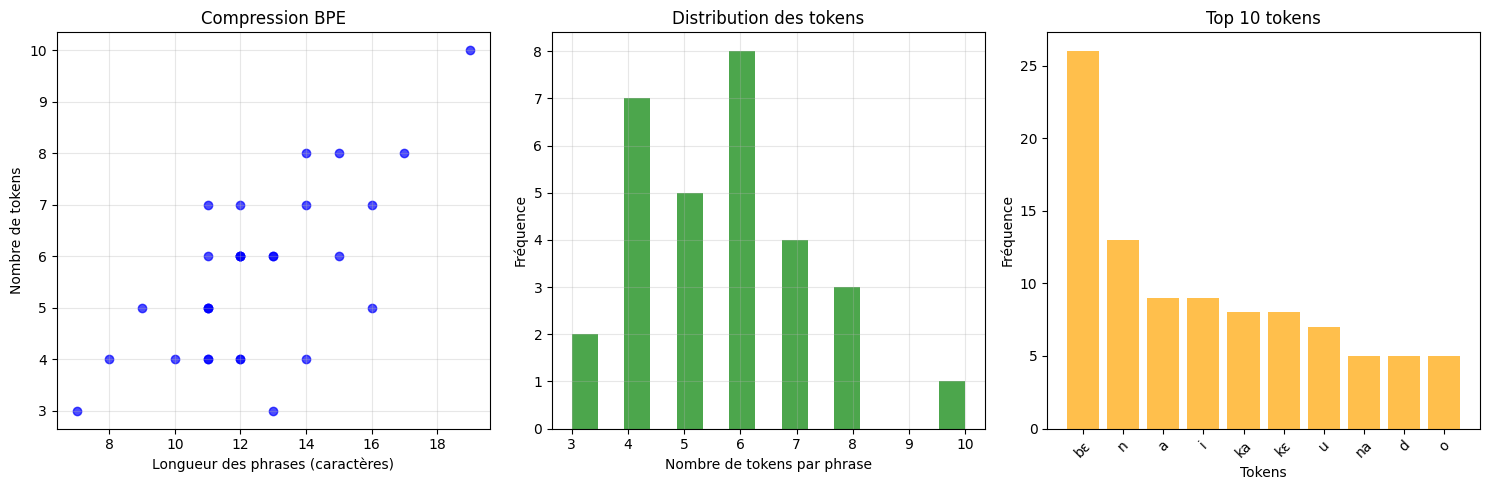

📈 Visualisations créées!


In [ ]:
# [8] VISUALISATION DES RÉSULTATS
import matplotlib.pyplot as plt

# Préparer les données pour la visualisation
sentence_lengths = []
token_counts = []

for phrase in bambara_corpus:
    tokens = bambara_tokenizer.encode(phrase)
    sentence_lengths.append(len(phrase))
    token_counts.append(len(tokens))

# Créer la visualisation
plt.figure(figsize=(15, 5))

# Graphique 1: Longueur des phrases vs nombre de tokens
plt.subplot(1, 3, 1)
plt.scatter(sentence_lengths, token_counts, alpha=0.7, color='blue')
plt.xlabel('Longueur des phrases (caractères)')
plt.ylabel('Nombre de tokens')
plt.title('Compression BPE')
plt.grid(True, alpha=0.3)

# Graphique 2: Distribution des longueurs de tokens
plt.subplot(1, 3, 2)
plt.hist(token_counts, bins=15, color='green', alpha=0.7)
plt.xlabel('Nombre de tokens par phrase')
plt.ylabel('Fréquence')
plt.title('Distribution des tokens')
plt.grid(True, alpha=0.3)

# Graphique 3: Top 20 des tokens
plt.subplot(1, 3, 3)
top_tokens = token_freq.most_common(10)
tokens, freqs = zip(*top_tokens)
plt.bar(range(len(tokens)), freqs, color='orange', alpha=0.7)
plt.xticks(range(len(tokens)), tokens, rotation=45)
plt.xlabel('Tokens')
plt.ylabel('Fréquence')
plt.title('Top 10 tokens')

plt.tight_layout()
plt.show()

print("📈 Visualisations créées!")